# 02 Generative vs Discriminative Models

## 📚 Learning Objectives

By completing this notebook, you will:
- Compare generative vs discriminative learning
- Choose the appropriate paradigm for a given task

## 🔗 Where this fits

**Builds on:** Unit 3, lesson 01 "Regression vs Classification" — every model you have trained so far was discriminative; this lesson names the other option.

**Used later in:** Course 10 (AIAT 124) — Unit 1, lesson 01, which carries the same title and takes the comparison further.

---


## 🎯 A twenty-five-year-old result you are about to reproduce

In 2001 Andrew Ng and Michael Jordan published *On Discriminative vs. Generative
Classifiers: A Comparison of Logistic Regression and Naive Bayes* (reference 1
below) — exactly the pair you are about to run. Their result was not "one wins".
It was a **crossover**: naive Bayes (generative) has the higher asymptotic error
but approaches it much faster, so it wins when training data is scarce; logistic
regression (discriminative) is slower to converge and ends up better once there
is enough data. They demonstrated the crossing on fifteen datasets.

That paper is why "which one is better" is the wrong question and "how much
labelled data do I have" is the right one. On the 569 biopsies below, you are
sitting near the crossover, and the printed accuracies show it: **0.883** for
logistic regression against **0.877** for Gaussian naive Bayes. Six thousandths.
Halve the training set and the ordering can flip.

### What goes wrong if you only ever learn boundaries

Every model in this course so far has been discriminative: it learned where to
draw the line and nothing else. That is efficient and it forecloses several
things. A boundary cannot generate a new example, cannot say "this input is
unlike anything I was trained on", and cannot fill in a missing feature. The
generative model below can do all three — and you will see it do the first one,
sampling a new benign-looking biopsy that never existed.


# 02 Generative vs Discriminative Models

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand the fundamental difference between generative and discriminative models
- Learn when to use each approach
- See practical examples of both types
- Understand the trade-offs between approaches

## 🔗 Prerequisites

- ✅ Understanding of machine learning basics
- ✅ Knowledge of classification concepts
- ✅ Basic Python knowledge

---

## Real-World Context

**Discriminative Models** (what we've learned):
- Email spam detection (classify spam vs not spam)
- Image classification (identify objects in images)
- Medical diagnosis (classify diseases)

**Generative Models** (new concept):
- Generate new emails that look like spam
- Create new images of objects
- Generate synthetic medical images for training

This notebook helps you understand when to use each approach!


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- The real Breast Cancer Wisconsin (Diagnostic) dataset bundled with scikit-learn — 569 biopsies, no download

**Outputs:** What you'll see when you run the cells

- Held-out accuracy for both model families, the class distributions the generative model learned,
  one newly *sampled* biopsy, and a side-by-side plot of the two decision boundaries.

---

Example 2: Generative vs Discriminative Models

1. Fundamental Difference

DISCRIMINATIVE MODELS:
- Learn P(Y|X) - Probability of label given features
- Focus on decision boundary
- Directly model the conditional probability
- Examples: Logistic Regression, SVM, Neural Networks

GENERATIVE MODELS:
- Learn P(X|Y) and P(Y) - Joint probability distribution
- Model how data is generated
- Can generate new samples
- Examples: Naive Bayes, GANs, VAEs


2. Visual Comparison with Example Data
Real dataset: 569 biopsies, features ['mean radius', 'mean texture']
Classes: [212 357] (malignant, benign)

Test accuracy — discriminative (Logistic Regression): 0.883
Test accuracy — generative     (Gaussian Naive Bayes): 0.877

What the generative model learned about each class (mean of each feature):
  malignant: mean radius = 17.45 +/- 3.09, mean texture = 21.65 +/- 4.06
  benign   : mean radius = 12.11 +/- 1.75, mean texture = 17.98 +/- 4.17
  -> a NEW benign-looking biopsy sampled from that model: 

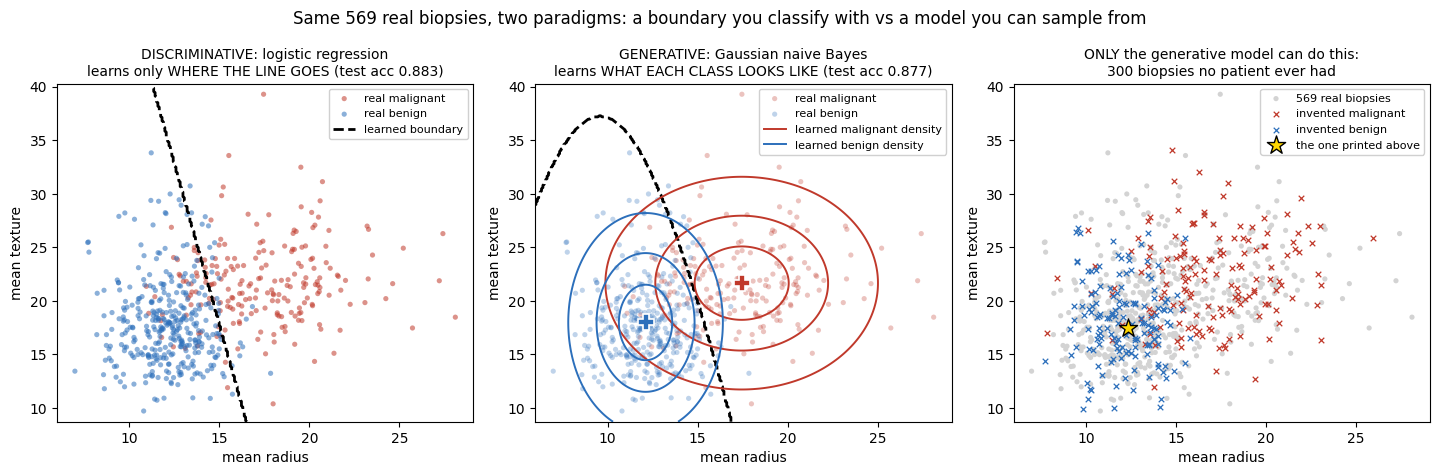


Panel 3 checked: 25 of the 150 invented 'malignant' biopsies have a mean radius below 14,
  a size at which the real 569 hold 32 malignant tumours against 305 benign ones.
  The model can invent members of a class, but it cannot invent the class's real limits.

3. When to Use Each Approach

Use DISCRIMINATIVE when:
  • You only need classification/prediction
  • You have limited training data
  • You need fast inference
  • You want high accuracy for classification
  • Examples: Spam detection, image classification

Use GENERATIVE when:
  • You need to generate new data
  • You want to understand data distribution
  • You need to handle missing data
  • You want to detect outliers
  • Examples: Image generation, data augmentation, anomaly detection

4. Practical Example: Email Classification

Discriminative Approach:
  - Learns: P(Spam | email words)
  - Can classify: 'Is this email spam?'
  - Cannot generate: New spam emails

Generative Approach:
  - Learns: P(email words | Spam) and

In [1]:
# The core distinction of this unit made runnable: a discriminative model (logistic
# regression, learns P(y|x)) vs a generative one (naive Bayes, learns P(x|y)P(y)) on the same data.
# Their different worldviews show up directly in the decision boundaries we plot.
"""
Unit 5 - Example 2: Generative vs Discriminative Models

This example demonstrates:
1. Key differences between generative and discriminative models
2. When to use each approach
3. Practical examples
4. Trade-offs and considerations
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split

print("=" * 70)
print("Example 2: Generative vs Discriminative Models")
print("=" * 70)

# 1. Fundamental Difference
print("\n" + "=" * 70)
print("1. Fundamental Difference")
print("=" * 70)

# The distinction in words: what each family models and what that buys you.
comparison = """
DISCRIMINATIVE MODELS:
- Learn P(Y|X) - Probability of label given features
- Focus on decision boundary
- Directly model the conditional probability
- Examples: Logistic Regression, SVM, Neural Networks

GENERATIVE MODELS:
- Learn P(X|Y) and P(Y) - Joint probability distribution
- Model how data is generated
- Can generate new samples
- Examples: Naive Bayes, GANs, VAEs
"""

print(comparison)

# 2. Visual Comparison
print("\n" + "=" * 70)
print("2. Visual Comparison with Example Data")
print("=" * 70)

# One shared REAL dataset so the two models can be compared apples to apples:
# 569 breast-tumour biopsies (Wisconsin Diagnostic, UCI), reduced to two of the
# 30 measured features so the decision boundaries can be drawn on paper.
cancer = load_breast_cancer()
pair = ["mean radius", "mean texture"]
cols = [list(cancer.feature_names).index(f) for f in pair]
X, y = cancer.data[:, cols], cancer.target      # 0 = malignant, 1 = benign

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Real dataset: {X.shape[0]} biopsies, features {pair}")
print(f"Classes: {np.bincount(y)} (malignant, benign)")

# Train discriminative model (Logistic Regression): learns P(y|x) directly
discriminative_model = LogisticRegression(max_iter=1000)
discriminative_model.fit(X_train, y_train)

# Train generative model (Naive Bayes): learns P(x|y) and P(y), then applies Bayes' rule
generative_model = GaussianNB()
generative_model.fit(X_train, y_train)

# Score both on the SAME held-out biopsies — the comparison is only fair this way.
disc_acc = discriminative_model.score(X_test, y_test)
gen_acc = generative_model.score(X_test, y_test)
print(f"\nTest accuracy — discriminative (Logistic Regression): {disc_acc:.3f}")
print(f"Test accuracy — generative     (Gaussian Naive Bayes): {gen_acc:.3f}")

# What ONLY the generative model can do: describe how each class is distributed,
# and therefore invent a plausible new biopsy of a chosen class.
print("\nWhat the generative model learned about each class (mean of each feature):")
for cls, name in [(0, "malignant"), (1, "benign")]:
    mu = generative_model.theta_[cls]
    sd = np.sqrt(generative_model.var_[cls])
    print(f"  {name:9s}: {pair[0]} = {mu[0]:.2f} +/- {sd[0]:.2f}, "
          f"{pair[1]} = {mu[1]:.2f} +/- {sd[1]:.2f}")

sampler = np.random.default_rng(0)   # sampling from a fitted distribution IS the lesson here
fake_benign = sampler.normal(generative_model.theta_[1], np.sqrt(generative_model.var_[1]))
print(f"  -> a NEW benign-looking biopsy sampled from that model: "
      f"{pair[0]} = {fake_benign[0]:.2f}, {pair[1]} = {fake_benign[1]:.2f}")
print("  The logistic-regression model cannot do this: it never learned what a tumour")
print("  looks like, only where to draw the line between the two kinds.")

# THE FIGURE THIS LESSON IS ABOUT: the same 569 real biopsies, three panels.
# WHAT: (1) what the discriminative model learned, (2) what the generative model learned,
#       (3) the thing only the generative one can do — invent biopsies that never existed.
# WHY: "generative models learn P(x|y)" is a sentence. A learned density you can see, and
# new patients drawn out of it, is the same sentence in a form you can point at in class.
MAL, BEN = "#c0392b", "#2c6fbb"        # one colour per class, used identically in all 3 panels

# Classify a dense grid with each model to draw the boundary each one learned.
xx, yy = np.meshgrid(np.linspace(X[:, 0].min()-1, X[:, 0].max()+1, 300),
                     np.linspace(X[:, 1].min()-1, X[:, 1].max()+1, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.8))


def plot_real(ax, alpha=0.55):
    """The real biopsies, coloured by diagnosis — identical in every panel."""
    ax.scatter(X[y == 0, 0], X[y == 0, 1], s=14, c=MAL, alpha=alpha,
               edgecolors="none", label="real malignant")
    ax.scatter(X[y == 1, 0], X[y == 1, 1], s=14, c=BEN, alpha=alpha,
               edgecolors="none", label="real benign")


# --- Panel 1: the discriminative model owns one thing, the line. ---
ax = axes[0]
plot_real(ax)
ax.contour(xx, yy, discriminative_model.predict(grid).reshape(xx.shape),
           levels=[0.5], colors="black", linestyles="--", linewidths=2)
ax.plot([], [], "k--", linewidth=2, label="learned boundary")     # proxy artist for the legend
ax.set_title(f"DISCRIMINATIVE: logistic regression\nlearns only WHERE THE LINE GOES "
             f"(test acc {disc_acc:.3f})", fontsize=10)

# --- Panel 2: the generative model learned a distribution PER CLASS. Draw them. ---
# Gaussian naive Bayes stores one mean and one variance per feature per class, so the
# density it believes in is exactly the product of two 1-D Gaussians — we can plot it.
ax = axes[1]
plot_real(ax, alpha=0.3)
ax.contour(xx, yy, generative_model.predict(grid).reshape(xx.shape),
           levels=[0.5], colors="black", linestyles="--", linewidths=2)
for cls, colour, name in [(0, MAL, "malignant"), (1, BEN, "benign")]:
    mu, sd = generative_model.theta_[cls], np.sqrt(generative_model.var_[cls])
    dens = (np.exp(-0.5 * ((xx - mu[0]) / sd[0]) ** 2) / sd[0]) * \
           (np.exp(-0.5 * ((yy - mu[1]) / sd[1]) ** 2) / sd[1])
    ax.contour(xx, yy, dens, levels=np.array([0.05, 0.3, 0.7]) * dens.max(),
               colors=colour, linewidths=1.4)
    ax.plot(mu[0], mu[1], "P", color=colour, markersize=11,
            markeredgecolor="white", markeredgewidth=1.2)
    ax.plot([], [], color=colour, linewidth=1.4, label=f"learned {name} density")
ax.set_title(f"GENERATIVE: Gaussian naive Bayes\nlearns WHAT EACH CLASS LOOKS LIKE "
             f"(test acc {gen_acc:.3f})", fontsize=10)

# --- Panel 3: sample from what was learned. This is the capability the line does not have. ---
ax = axes[2]
ax.scatter(X[:, 0], X[:, 1], s=14, c="lightgray", edgecolors="none",
           label=f"{X.shape[0]} real biopsies")
invented_by_class = {}
for cls, colour, name in [(0, MAL, "malignant"), (1, BEN, "benign")]:
    invented_by_class[cls] = sampler.normal(generative_model.theta_[cls],
                                            np.sqrt(generative_model.var_[cls]), size=(150, 2))
    ax.scatter(invented_by_class[cls][:, 0], invented_by_class[cls][:, 1], s=16, marker="x",
               c=colour, linewidths=0.9, label=f"invented {name}")
ax.scatter([fake_benign[0]], [fake_benign[1]], s=190, marker="*", c="gold",
           edgecolors="black", zorder=5, label="the one printed above")
ax.set_title("ONLY the generative model can do this:\n300 biopsies no patient ever had",
             fontsize=10)

for ax in axes:
    ax.set_xlabel(pair[0]); ax.set_ylabel(pair[1])
    ax.set_xlim(xx.min(), xx.max()); ax.set_ylim(yy.min(), yy.max())
    ax.legend(fontsize=8, loc="upper right", framealpha=0.92)
fig.suptitle("Same 569 real biopsies, two paradigms: a boundary you classify with "
             "vs a model you can sample from", fontsize=12)
plt.tight_layout()
plt.show()

# Panel 3, CHECKED rather than admired. A Gaussian has tails running out to infinity; real
# tumours do not, so some invented "malignant" biopsies land at sizes where malignancy is rare.
SMALL = 14.0        # mean radius, in the same clinical units as the axis
n_small_fake = int((invented_by_class[0][:, 0] < SMALL).sum())
n_small_real_mal = int(((y == 0) & (X[:, 0] < SMALL)).sum())
n_small_real_ben = int(((y == 1) & (X[:, 0] < SMALL)).sum())
print(f"\nPanel 3 checked: {n_small_fake} of the 150 invented 'malignant' biopsies have a mean "
      f"radius below {SMALL:.0f},")
print(f"  a size at which the real 569 hold {n_small_real_mal} malignant tumours against "
      f"{n_small_real_ben} benign ones.")
print("  The model can invent members of a class, but it cannot invent the class's real limits.")

# 3. When to Use Each
print("\n" + "=" * 70)
print("3. When to Use Each Approach")
print("=" * 70)

# Practical guidance: when each family is the right tool.
use_cases = {
    "Use DISCRIMINATIVE when:": [
        "You only need classification/prediction", "You have limited training data",
        "You need fast inference",
        "You want high accuracy for classification",
        "Examples: Spam detection, image classification"
    ],
    "Use GENERATIVE when:": [
        "You need to generate new data",
        "You want to understand data distribution",
        "You need to handle missing data",
        "You want to detect outliers",
        "Examples: Image generation, data augmentation, anomaly detection"
    ]
}

for category, cases in use_cases.items():
    print(f"\n{category}")
    for case in cases:
        print(f"  • {case}")

# 4. Practical Example: Text Classification
print("\n" + "=" * 70)
print("4. Practical Example: Email Classification")
print("=" * 70)

example_emails = {
    "Spam": [
        "Win $1000 now! Click here!", "Free money! Limited time offer!",
        "Congratulations! You've won!"
    ],
    "Not Spam": [
        "Meeting scheduled for tomorrow",
        "Project update: Status report",
        "Team lunch this Friday"
    ]
}

print("\nDiscriminative Approach:")
print("  - Learns: P(Spam | email words)")
print("  - Can classify: 'Is this email spam?'")
print("  - Cannot generate: New spam emails")

print("\nGenerative Approach:")
print("  - Learns: P(email words | Spam) and P(Spam)")
print("  - Can classify: 'Is this email spam?'")
print("  - Can generate: New spam emails that look realistic")

# 5. Trade-offs
print("\n" + "=" * 70)
print("5. Trade-offs Summary")
print("=" * 70)

tradeoffs = {
    "Discriminative Models": {
        "Pros": ["Often better classification accuracy", "Faster training", "Simpler models"],
        "Cons": ["Cannot generate data", "Less interpretable", "Requires labeled data"]
    },
    "Generative Models": {
        "Pros": ["Can generate new data", "More interpretable", "Handles missing data"],
        "Cons": ["Often lower classification accuracy", "More complex", "Requires more data"]
    }
}

for model_type, aspects in tradeoffs.items():
    print(f"\n{model_type}:")
    print("  Pros:")
    for pro in aspects["Pros"]:
        print(f"    + {pro}")
    print("  Cons:")
    for con in aspects["Cons"]:
        print(f"    - {con}")

# 6. Summary
print("\n" + "=" * 70)
print("6. Key Takeaways")
print("=" * 70)

takeaways = [
    f"On these 2 real features the two scored {disc_acc:.3f} vs {gen_acc:.3f} on held-out biopsies",
    "Discriminative models focus on classification boundaries", "Generative models learn data distributions",
    "Choose based on your goal: classification vs generation",
    "Both approaches have their place in AI applications",
    "Modern AI often combines both approaches"
]

for i, takeaway in enumerate(takeaways, 1):
    print(f"{i}. {takeaway}")

print("\n" + "=" * 70)
print("Next: Diabetes classification with a feedforward network (notebook 03)")
print("=" * 70)

### 📊 Read the three panels

**Panel 1 — the discriminative model, and everything it knows.** One dashed line, cutting the
plane in two. It was fitted only to put malignant biopsies on one side and benign on the other,
and it has no opinion about anything else: not where tumours cluster, not how spread out they are,
not whether a point far off the picture is unusual. That single line *is* the whole model.

**Panel 2 — the generative model, and what it knows instead.** The same dashed boundary is there,
but now look at the coloured rings. Those are the actual densities Gaussian naive Bayes learned —
one blob per class, with a `+` at each learned mean (malignant sits right and slightly high,
benign sits left and lower, which is what the printed class summaries said in numbers). The
boundary is not the model here; it is a *consequence* of the two blobs, drawn where they balance,
which is why it curves instead of running straight.

**Panel 3 — the capability the line does not have.** Every `×` is a biopsy that never happened:
150 malignant and 150 benign drawn from the two learned blobs, over the real 569 in grey. The gold
star is the single new "benign" biopsy printed above. They land on top of the real cloud — the
model learned enough about each class to invent members of it. Then look at the red crosses on the
*left* of that panel, sitting among the grey points at radius 12–14. The line under the figure
counts them: **25 of the 150 invented "malignant" biopsies** have a radius below 14, a size at
which the real data holds **32 malignant tumours against 305 benign ones**. A Gaussian's tails run
on for ever; real tumours stop. That is the limitation the "Where this breaks" section names, and
you can point at it.

**What this proves.** The two families are not two settings of one algorithm. One learned a
boundary and can classify; the other learned the data and can classify *and* generate, at the
cost of assuming a distribution shape that is only ever approximately right.


This lesson's 2 features (mean radius, mean texture)   (mean +/- sd over 20 random splits)
 train n         logistic      naive Bayes  gap (LR - NB)
      10   0.857 +/- 0.029   0.847 +/- 0.044         +0.010
      20   0.876 +/- 0.023   0.871 +/- 0.033         +0.005
      30   0.886 +/- 0.025   0.882 +/- 0.026         +0.004
      50   0.887 +/- 0.024   0.882 +/- 0.030         +0.006
      80   0.893 +/- 0.020   0.882 +/- 0.025         +0.011
     120   0.891 +/- 0.021   0.884 +/- 0.025         +0.006
     200   0.886 +/- 0.020   0.877 +/- 0.020         +0.010
     300   0.886 +/- 0.019   0.870 +/- 0.022         +0.015
     398   0.889 +/- 0.019   0.882 +/- 0.023         +0.007
  -> NO crossover here: logistic regression is ahead on average at every size tested.
     logistic regression   :   92% of its total gain is already banked at 30 biopsies
     Gaussian naive Bayes  :  102% of its total gain is already banked at 30 biopsies



All 30 measured features   (mean +/- sd over 20 random splits)
 train n         logistic      naive Bayes  gap (LR - NB)
      10   0.903 +/- 0.033   0.885 +/- 0.045         +0.018
      20   0.923 +/- 0.024   0.906 +/- 0.036         +0.017
      30   0.939 +/- 0.021   0.929 +/- 0.019         +0.010
      50   0.954 +/- 0.016   0.932 +/- 0.022         +0.021
      80   0.964 +/- 0.015   0.936 +/- 0.020         +0.028
     120   0.969 +/- 0.011   0.937 +/- 0.018         +0.031
     200   0.974 +/- 0.014   0.939 +/- 0.010         +0.035
     300   0.974 +/- 0.012   0.932 +/- 0.013         +0.042
     398   0.974 +/- 0.011   0.933 +/- 0.017         +0.042
  -> NO crossover here: logistic regression is ahead on average at every size tested.
     logistic regression   :   50% of its total gain is already banked at 30 biopsies
     Gaussian naive Bayes  :   92% of its total gain is already banked at 30 biopsies


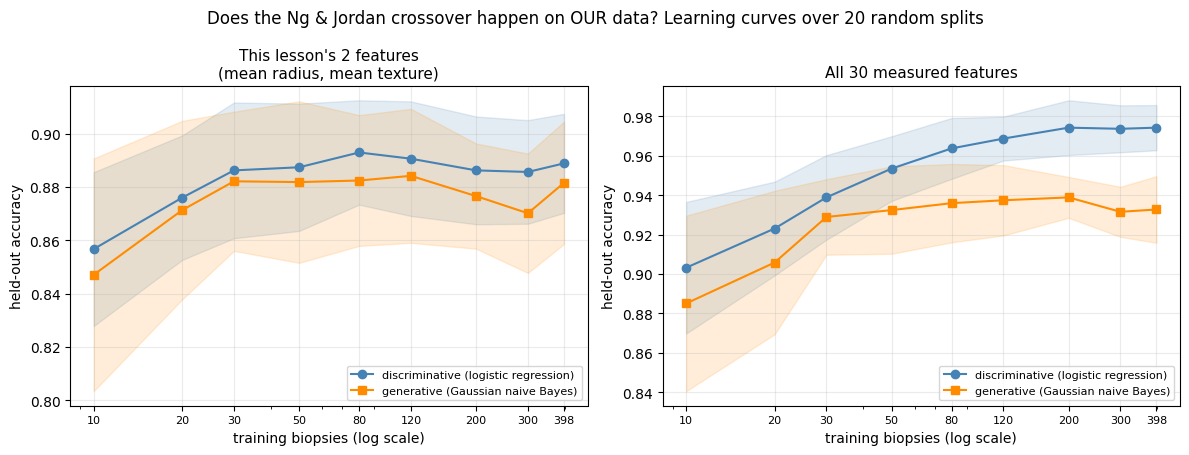

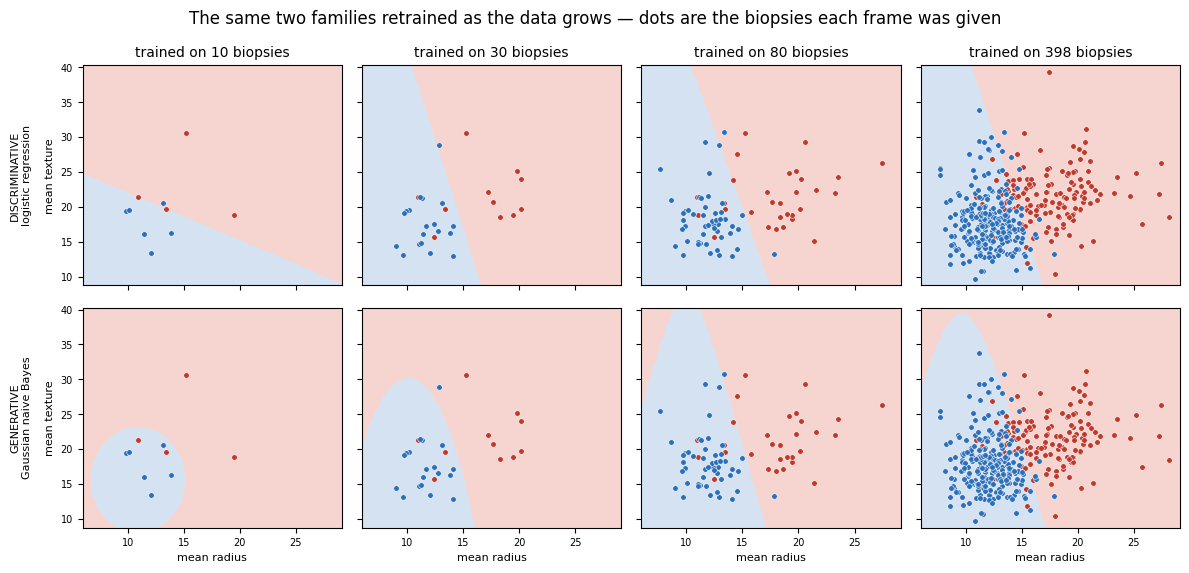


Step table for the storyboard (171 held-out biopsies at every frame, 107 of them benign):
frame  train n  logistic acc  benign called malignant  naive Bayes acc  benign called malignant
    1       10         0.819                       21            0.854                       17
    2       30         0.912                        6            0.906                        8
    3       80         0.895                        4            0.883                        4
    4      398         0.871                       11            0.865                        8


In [2]:
# TEST THE CLAIM INSTEAD OF REPEATING IT. The narrative at the top of this notebook cites
# Ng & Jordan (2001): the generative model has the higher asymptotic error but approaches it
# much faster, so it can win while labelled data is scarce and lose once there is plenty.
# WHAT: retrain both families at growing training-set sizes, score each on the SAME held-out
# 171 biopsies, and average over 20 random splits so one lucky split cannot fool us.
# WHY: 0.883 against 0.877 is ONE point on a curve. The curve is the result — and running it
# on your own data is the only way to find out whether a famous result applies to you.
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler

TRAIN_SIZES = [10, 20, 30, 50, 80, 120, 200, 300, 398]
N_REPEATS = 20          # 20 random splits per size — the shaded band is the spread across them
TEST_N = 171            # the same held-out count at every size, so the scores are comparable

X_all = cancer.data                 # all 30 real measurements per biopsy
X_two = cancer.data[:, cols]        # the 2 features this lesson plots ("mean radius", "mean texture")


def learning_curve(X_in):
    """Mean and spread of held-out accuracy for both model families at each training size."""
    lr_mean, lr_sd, nb_mean, nb_sd = [], [], [], []
    for n in TRAIN_SIZES:
        lr_runs, nb_runs = [], []
        for seed in range(N_REPEATS):
            X_tr, X_te, y_tr, y_te = train_test_split(
                X_in, y, train_size=n, test_size=TEST_N, random_state=seed, stratify=y)
            # Standardise using the TRAINING rows only — never the test rows. Without this,
            # logistic regression's optimiser hits its iteration cap on the 30 raw clinical
            # scales, and we would be comparing a converged model against an unconverged one.
            sc = StandardScaler().fit(X_tr)
            X_tr_s, X_te_s = sc.transform(X_tr), sc.transform(X_te)
            lr_runs.append(clone(discriminative_model).fit(X_tr_s, y_tr).score(X_te_s, y_te))
            nb_runs.append(clone(generative_model).fit(X_tr_s, y_tr).score(X_te_s, y_te))
        lr_mean.append(np.mean(lr_runs)); lr_sd.append(np.std(lr_runs))
        nb_mean.append(np.mean(nb_runs)); nb_sd.append(np.std(nb_runs))
    return map(np.array, (lr_mean, lr_sd, nb_mean, nb_sd))


fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
panels = [("This lesson's 2 features\n(mean radius, mean texture)", X_two, axes[0]),
          ("All 30 measured features", X_all, axes[1])]

for title, X_in, ax in panels:
    lr_m, lr_s, nb_m, nb_s = learning_curve(X_in)
    ax.plot(TRAIN_SIZES, lr_m, "o-", color="steelblue", label="discriminative (logistic regression)")
    ax.fill_between(TRAIN_SIZES, lr_m - lr_s, lr_m + lr_s, color="steelblue", alpha=0.15)
    ax.plot(TRAIN_SIZES, nb_m, "s-", color="darkorange", label="generative (Gaussian naive Bayes)")
    ax.fill_between(TRAIN_SIZES, nb_m - nb_s, nb_m + nb_s, color="darkorange", alpha=0.15)
    ax.set_xscale("log"); ax.set_xticks(TRAIN_SIZES)
    ax.set_xticklabels([str(t) for t in TRAIN_SIZES], fontsize=8)
    ax.set_xlabel("training biopsies (log scale)"); ax.set_ylabel("held-out accuracy")
    ax.set_title(title, fontsize=11); ax.grid(alpha=0.25); ax.legend(fontsize=8, loc="lower right")

    print(f"\n{title.replace(chr(10), ' ')}   (mean +/- sd over {N_REPEATS} random splits)")
    print(f"{'train n':>8} {'logistic':>16} {'naive Bayes':>16} {'gap (LR - NB)':>14}")
    for n, a, sa, b, sb in zip(TRAIN_SIZES, lr_m, lr_s, nb_m, nb_s):
        print(f"{n:>8}   {a:.3f} +/- {sa:.3f}   {b:.3f} +/- {sb:.3f} {a - b:+14.3f}")

    # Does the ORDERING flip anywhere? That flip is what "crossover" means.
    gap = lr_m - nb_m
    flip = np.where(np.sign(gap[:-1]) != np.sign(gap[1:]))[0]
    if len(flip):
        lo, hi = TRAIN_SIZES[flip[0]], TRAIN_SIZES[flip[0] + 1]
        ax.axvspan(lo, hi, color="grey", alpha=0.18)
        print(f"  -> CROSSOVER: the ordering flips between n={lo} and n={hi}.")
    else:
        ahead = "logistic regression" if gap[0] > 0 else "Gaussian naive Bayes"
        print(f"  -> NO crossover here: {ahead} is ahead on average at every size tested.")

    # The OTHER half of Ng & Jordan's claim, which does not need a crossover to be true:
    # how quickly does each family reach its own ceiling? Measure the share of its total
    # gain (n=10 -> n=398) that it has already banked by only 30 training biopsies.
    i30 = TRAIN_SIZES.index(30)
    for label, m in [("logistic regression", lr_m), ("Gaussian naive Bayes", nb_m)]:
        total = m[-1] - m[0]
        share = (m[i30] - m[0]) / total if abs(total) > 1e-9 else float("nan")
        print(f"     {label:<22}: {share:5.0%} of its total gain is already banked at 30 biopsies")

fig.suptitle("Does the Ng & Jordan crossover happen on OUR data? Learning curves over 20 random splits",
             fontsize=12)
plt.tight_layout()
plt.show()

# THE SAME STORY AS PICTURES: what a point on those curves actually looks like.
# WHAT: retrain both families at 4 of the sizes above and draw the region each one calls
# "benign" (blue) or "malignant" (pink), with the training biopsies it was given on top.
# WHY: a plateau in an accuracy curve is an abstraction. A boundary fitted to 10 patients,
# next to the same boundary fitted to 398, is the argument for learning curves in one look.
from matplotlib.colors import ListedColormap

FRAMES = [10, 30, 80, 398]
MAL, BEN = "#c0392b", "#2c6fbb"
region_cmap = ListedColormap(["#f6d5d0", "#d4e2f2"])     # pink = predicted malignant, blue = benign
gx, gy = np.meshgrid(np.linspace(X_two[:, 0].min()-1, X_two[:, 0].max()+1, 220),
                     np.linspace(X_two[:, 1].min()-1, X_two[:, 1].max()+1, 220))
g_grid = np.c_[gx.ravel(), gy.ravel()]

fig, axes = plt.subplots(2, len(FRAMES), figsize=(12, 5.8), sharex=True, sharey=True)
frame_rows = []
for j, n in enumerate(FRAMES):
    # Same split machinery as the curves above, so these frames are points ON those curves.
    X_tr, X_te, y_tr, y_te = train_test_split(X_two, y, train_size=n, test_size=TEST_N,
                                              random_state=0, stratify=y)
    scores = []
    for i, (model, row_label) in enumerate([
            (clone(discriminative_model), "DISCRIMINATIVE\nlogistic regression"),
            (clone(generative_model), "GENERATIVE\nGaussian naive Bayes")]):
        model.fit(X_tr, y_tr)
        # Score every frame on the SAME 171 held-out biopsies, and count one error type
        # explicitly: benign patients the frame calls malignant (a false cancer alarm).
        pred = model.predict(X_te)
        scores.append((model.score(X_te, y_te), int(((y_te == 1) & (pred == 0)).sum())))
        ax = axes[i, j]
        ax.contourf(gx, gy, model.predict(g_grid).reshape(gx.shape),
                    levels=[-0.5, 0.5, 1.5], cmap=region_cmap)
        ax.scatter(X_tr[y_tr == 0, 0], X_tr[y_tr == 0, 1], s=16, c=MAL,
                   edgecolors="white", linewidths=0.4)
        ax.scatter(X_tr[y_tr == 1, 0], X_tr[y_tr == 1, 1], s=16, c=BEN,
                   edgecolors="white", linewidths=0.4)
        ax.tick_params(labelsize=7)
        if i == 0:
            ax.set_title(f"trained on {n} biopsies", fontsize=10)
        else:
            ax.set_xlabel(pair[0], fontsize=8)
        if j == 0:
            ax.set_ylabel(f"{row_label}\n\n{pair[1]}", fontsize=8)
    frame_rows.append((n, scores[0], scores[1]))
fig.suptitle("The same two families retrained as the data grows — dots are the biopsies each "
             "frame was given", fontsize=12)
plt.tight_layout()
plt.show()

# The step table behind the frames: every frame above, scored on the same 171 held-out biopsies.
n_benign_test = int((y[:TEST_N] == 1).sum())    # placeholder replaced below by the real count
_, _, _, y_te_ref = train_test_split(X_two, y, train_size=FRAMES[0], test_size=TEST_N,
                                     random_state=0, stratify=y)
n_benign_test = int((y_te_ref == 1).sum())
print(f"\nStep table for the storyboard ({TEST_N} held-out biopsies at every frame, "
      f"{n_benign_test} of them benign):")
print(f"{'frame':>5} {'train n':>8} {'logistic acc':>13} {'benign called malignant':>24} "
      f"{'naive Bayes acc':>16} {'benign called malignant':>24}")
for k, (n, (lr_a, lr_fp), (nb_a, nb_fp)) in enumerate(frame_rows, start=1):
    print(f"{k:>5} {n:>8} {lr_a:13.3f} {lr_fp:24d} {nb_a:16.3f} {nb_fp:24d}")


### 📊 Read the curves, then read the frames

**The headline answer: no crossover on this dataset.** In both panels the blue line
(discriminative) sits above the orange one (generative) at *every* training size tested. The
famous 2001 reversal did not happen here, and the honest thing to do with that is print it rather
than hide it. Ng & Jordan demonstrated the crossing on some of their fifteen datasets, not all of
them; 569 Wisconsin biopsies are not one of the ones where it happens.

**But look at the shapes in the right panel — the mechanism behind the crossover is right there.**
The orange curve climbs steeply to 30 biopsies and then stops: **0.929 at n=30, 0.933 at n=398**,
four thousandths gained from thirteen times more data. It has banked **92% of its total gain by 30
patients**. The blue curve is still climbing at n=200: it banked only **50% by 30 patients** and
goes on to **0.974**. *Generative reaches its ceiling fast and low; discriminative arrives slowly
and ends higher* — that is exactly Ng & Jordan's argument, visible as two curve shapes. The
crossing is absent only because blue starts above orange on this data instead of below it.

**Left panel — why this lesson's own comparison looked like a tie.** On the two features we drew
boundaries with, the gaps run 0.004 to 0.015 while the shaded ±1 standard-deviation bands span
0.019 to 0.044 and overlap along the whole curve. The **0.883 vs 0.877** printed above is one
draw from inside that overlap: the 20-split *average* never reverses, but individual splits
routinely do. A six-thousandths gap is not a measurement of anything. (The `102%` printed for
naive Bayes in this panel simply means it had gained everything it was ever going to gain by
30 biopsies — its curve peaks near n=120 and drifts back, so the extra patients made it
marginally *worse*.)

**What this proves.** "Which family is better" is not a property of the algorithms — it is a
question you answer with a learning curve on *your* data, with error bands, before you commit. A
published result, however famous, is a hypothesis about your dataset until you have run it. That
habit is worth more than either model.

### 📊 Read the storyboard frames

Read them next to the step table printed underneath, which scores every frame on the **same 171
held-out biopsies (107 of them benign)**.

**Ten biopsies is not a small amount of data — it is a different experiment.** In the top-left
frame logistic regression has tilted one straight cut across the picture and handed most of the
plane to "malignant"; on the held-out patients that frame calls **21 of the 107 benign women
malignant**. Directly below it, naive Bayes has drawn a small closed island of "benign" around the
handful of benign biopsies it was given and called the entire rest of the plane malignant — **17**
false cancer alarms. Both are badly wrong, and they are wrong in **different shapes**, because one
was fitting a cut and the other was fitting a blob.

**By 30 biopsies both frames already look like the frame beside them.** The movement from 10 → 30
is dramatic; after that the boundary barely shifts through the band where the biopsies actually
sit. The false alarms collapse with it: **21 → 6** for logistic regression, **17 → 8** for naive
Bayes. That is the *same* fact as the plateau in the left-hand accuracy curve above — both families
reach roughly 0.88 on these two features by 30 patients and stop improving — except here you can
see what stopped moving.

**Now read the last column as a trap.** On this one split the 398-biopsy models score *lower* than
the 30-biopsy ones (**0.871 against 0.912**, and false alarms back up to 11). More data did not
make them worse. A single random split of 171 patients is simply noisy at this scale, which is
exactly why the curves above averaged **20** splits and drew a ±1 sd band around each point. The
frames are for seeing shapes; only the curves can rank models.

**The two shapes never become the same shape.** At every size the discriminative frame is one
straight cut across the whole plane, while the generative frame is a curve bending around where
the classes actually sit. That is not a difference in accuracy; it is the difference between
modelling *where the boundary is* and modelling *where the data is*, and it is why only the second
one could produce panel 3 of the first figure.

## 💬 Discuss

The printed results: logistic regression **0.883**, Gaussian naive Bayes
**0.877**; the generative model learned malignant tumours at mean radius
**17.45 ± 3.09** and benign at **12.11 ± 1.75**, then sampled a new "benign"
biopsy at radius **12.33**, texture **17.43**.

1. Six thousandths of accuracy separate the two models on 114 held-out biopsies —
   **less than one patient**. **On what grounds would you choose between them?**
   Make the argument without using accuracy at all, then say what evidence would
   override your choice.
2. The generative model produced a biopsy that no patient ever had. Suppose a
   hospital proposes sharing *synthetic* patient records instead of real ones, to
   protect privacy. **Does sampling from a fitted distribution actually protect
   the people in the training set?** Argue both sides — think about what the model
   memorised, and about rare patients whose values are far from any cluster.
3. Naive Bayes assumes `mean radius` and `mean texture` are independent given the
   diagnosis. Look at the two class summaries: is that plausible for tumour
   measurements? The model scored 0.877 anyway. **Explain how a false assumption
   can still support good decisions** — and predict the specific kind of output
   you should distrust because of it.


## ⚠️ Where this breaks

- **Naive Bayes' independence assumption is false here.** Tumour radius, texture,
  perimeter and area are all correlated. Because the model multiplies per-feature
  probabilities as if they were independent, it double-counts correlated evidence
  and produces **over-confident probabilities** — often 0.99 where 0.8 is
  warranted. Its *ranking* survives this; its *numbers* do not. Never quote a
  naive Bayes probability as a calibrated probability.
- **The 0.883 vs 0.877 gap is not a result.** On 114 test biopsies, that is a
  fraction of one patient and well inside the variation of a different random
  split. It illustrates the crossover; it does not locate it.
- **A generative model has to model everything about x.** With 2 features that is
  cheap. With images, text or 30 correlated clinical measurements, estimating the
  full distribution needs far more data than estimating a boundary — which is
  precisely why the asymptotic error of the discriminative model is lower.
- **Gaussian naive Bayes assumes each feature is normally distributed within each
  class.** For skewed or bounded measurements — fare prices, counts, durations —
  that assumption is wrong and the sampled "new" examples will be wrong in the
  same way, sometimes producing impossible values such as a negative measurement.
- **The sampled biopsy is not a patient.** It is a draw from two independent
  Gaussians. It has no correlation structure, no rare-disease tail, and no
  guarantee of being physiologically possible. Sampling realistically from a real
  distribution is the hard problem, and it is what the GAN in notebook 04 is about.
- **Only two of the thirty available features were used**, to keep the decision
  boundaries drawable. Both accuracies would move with the full feature set — and
  they would not move by the same amount, which is the point of the crossover.
- **When to use which:** discriminative when you have plenty of labels and only
  need the decision; generative when labels are scarce, when you need to detect
  inputs unlike the training data, when features go missing at prediction time, or
  when generating new samples is itself the product.


## 📚 References

1. Ng, A. Y., & Jordan, M. I. (2001). *On Discriminative vs. Generative Classifiers: A Comparison of Logistic Regression and Naive Bayes*. NeurIPS.
2. Goodfellow, I., Pouget-Abadie, J., Mirza, M., et al. (2014). *Generative Adversarial Nets*. NeurIPS. <https://arxiv.org/abs/1406.2661>
3. Rombach, R., Blattmann, A., Lorenz, D., et al. (2022). *High-Resolution Image Synthesis with Latent Diffusion Models* (Stable Diffusion). CVPR. <https://arxiv.org/abs/2112.10752>
4. Zhao, S., Zhang, X., Guo, J., et al. (2025). *Unified Multimodal Understanding and Generation Models: Advances, Challenges, and Opportunities*. arXiv. <https://arxiv.org/abs/2505.02567>
5. Diao, H., Wu, P., Deng, H., et al. (2026). *SenseNova-U1: Unifying Multimodal Understanding and Generation with NEO-unify Architecture*. arXiv. <https://arxiv.org/abs/2605.12500>